In [2]:
### Trends in the proteomics

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [3]:
clin = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/clin_ready.csv', header = 0, index_col=0)
prot = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/raw_data_proteins_filtered.csv',header = 0, index_col = 0)
prot_list = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/prot_filtered.csv', header = 0, index_col=0)

prot = prot.filter(prot_list.iloc[:,0], axis = 1)
prot = prot.drop(labels = [1578], axis = 0)
clin = clin.drop(labels = [1578], axis = 0)
print('clin:', clin.shape)
print('prot:', prot.shape)

list_groups = []
for i in clin['iss']:
    if i<=3:
        list_groups.append("Low")
    elif i>3 and i<= 8:
        list_groups.append("Mild")
    elif i>=9 and i<=15:
        list_groups.append("Moderate")
    elif i>15 and i<25:
        list_groups.append("Severe")
    else:
        list_groups.append("Critical")

groups = pd.DataFrame(list_groups, columns  = (['Severity']))
print("Total number of patients is",len(list_groups))

groups = groups.set_index(clin.index)
clin =  clin.join(groups)

print(" ")
for i in pd.Series(list_groups).unique():
    print(i, clin[clin['Severity'] == i].shape)


clin: (414, 38)
prot: (414, 4979)
Total number of patients is 414
 
Mild (77, 39)
Critical (108, 39)
Moderate (79, 39)
Severe (77, 39)
Low (73, 39)


In [4]:
## functions
def get_df_means(group):
    idx_g = clin[clin['Severity'] == group].index
    df = X.filter(items = idx_g, axis = 0)
    return df.mean()

def scale(data):
    scaler = MinMaxScaler()
    scaler.fit(data)
    X= scaler.transform(data)
    X= pd.DataFrame(X)
    X.columns= data.columns
    X = X.set_index(data.index)
    return X

def plot_figure(rows, cols, data):
    sns.set_theme(style = "whitegrid")
    fig, axs = plt.subplots(rows, cols, figsize=(cols*4,rows*3.5), squeeze=False)
    counter=0
    for r in range(rows):
        for c in range(cols):
            if counter>=len(data):
                break  
            i = data.columns[counter]
            
            # plot setting
            sns.barplot(x = clin['Severity'], y = data.iloc[:,counter], 
            order = ['Low','Mild', 'Moderate','Severe','Critical'], 
            ax = axs[r][c], 
            palette = "coolwarm").set_title(i.split(".")[0])

            counter+=1
    plt.tight_layout()
    plt.show()


In [5]:
# scale data with MinMax because we don't want to have negatives
X = scale(prot)
means=[]
for group in ['Low','Mild', 'Moderate','Severe','Critical']:
    means.append(get_df_means(group))
    
means_df = pd.DataFrame(means[0], columns = ["controls"])
means_df['low'] = means[1]
means_df['moderate'] = means[2]
means_df['severe'] = means[3]
means_df['critical'] = means[4]

In [6]:
# check for trends
index_increase= []
index_decrease= []
index_fluctuate = []
for r in means_df.index:
    if means_df.loc[r,'low']> means_df.loc[r,'controls'] and means_df.loc[r,'moderate']> means_df.loc[r,'low'] and means_df.loc[r,'severe']> means_df.loc[r,'moderate'] and means_df.loc[r,'critical']> means_df.loc[r,'severe']:
        index_increase.append(r)
    elif means_df.loc[r,'low']< means_df.loc[r,'controls'] and means_df.loc[r,'moderate']< means_df.loc[r,'low'] and means_df.loc[r,'severe']< means_df.loc[r,'moderate'] and means_df.loc[r,'critical']< means_df.loc[r,'severe']:
        index_decrease.append(r)
    else:
        index_fluctuate.append(r)
        
print("Proteins that increase with severity:", len(index_increase))
print("Proteins that decrease with severity:", len(index_decrease))
print("Proteins that fluctuate:", len(index_fluctuate))

Proteins that increase with severity: 3271
Proteins that decrease with severity: 37
Proteins that fluctuate: 1671


In [7]:
# ratio between cols
prot_incr = means_df.filter(items = index_increase,axis = 0)
prot_incr.shape
df_len2  = len(prot_incr)
d2 = {'ratio1': np.zeros(df_len2), 'ratio2': np.zeros(df_len2)}
df_ratio = pd.DataFrame(data=d2, index = prot_incr.index)
df_ratio
df_ratio['ratio1'] = prot_incr['moderate']/prot_incr['low']
df_ratio['ratio2'] = prot_incr['severe']/prot_incr['moderate']
df_ratio['ratio3'] = prot_incr['critical']/prot_incr['severe']
df_ratio['mean'] = df_ratio.mean(axis = 1)
df_ratio['st_dev'] = df_ratio.std(axis = 1)

# calculating the ones fitting an exp
factor = 0.1
proteins = df_ratio['st_dev'] < (df_ratio['mean']*factor)
exp_df =  df_ratio[proteins]

# setting base and std
base = 1.6
sig_base = exp_df[exp_df['mean']> base]
index_exp_prot = sig_base.index
print(len(index_exp_prot))

47


In [10]:
# exp df
df_to_use = X.filter(items =index_exp_prot)
df_to_use.shape[1] 
biom_names = [i.split(".")[0] for i in df_to_use.columns]

# pass the exponential proteins in an enrichment tool to check what pathways are they associated to
import enrich_omics
from enrich_omics import EnrichR

EnrichR.plot_enrichment(biom_names, library_name = 'BioPlanet_2019', max_hits=10, width=345)


alt.LayerChart(...)

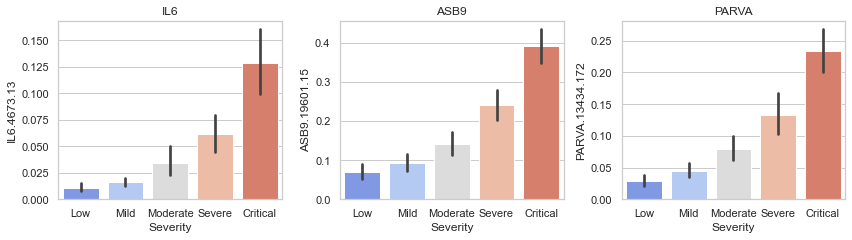

In [11]:
#plot the exp proteins
subset_exp = X.filter(items = ['IL6.4673.13','ASB9.19601.15','PARVA.13434.172'])
plot_figure(1, 3, subset_exp)
#plt.savefig("/Users/smasarone/Documents/exp.pdf")      


In [12]:
## prot decrease with sev
prot_decr = means_df.filter(items = index_decrease, axis = 0)

df_len_dec  = len(prot_decr)
d_decr = {'ratio1': np.zeros(df_len_dec), 'ratio2': np.zeros(df_len_dec)}
df_ratio_decr = pd.DataFrame(data=d_decr, index = prot_decr.index)

df_ratio_decr['ratio1'] = prot_decr['moderate']/prot_decr['low']
df_ratio_decr['ratio2'] = prot_decr['severe']/prot_decr['moderate']
df_ratio_decr['ratio3'] = prot_decr['critical']/prot_decr['severe']
df_ratio_decr['mean'] = df_ratio_decr.mean(axis = 1)
df_ratio_decr['st_dev'] = df_ratio_decr.std(axis = 1)


In [28]:
#names of prot that decrease with severity 
# add this for the thesis 
df_ratio_decr.index 
decreasing_prot = [i.split(".")[0] for i in df_ratio_decr.index]

EnrichR.plot_enrichment(decreasing_prot, library_name = 'BioPlanet_2019', max_hits=10, width=345)

alt.LayerChart(...)

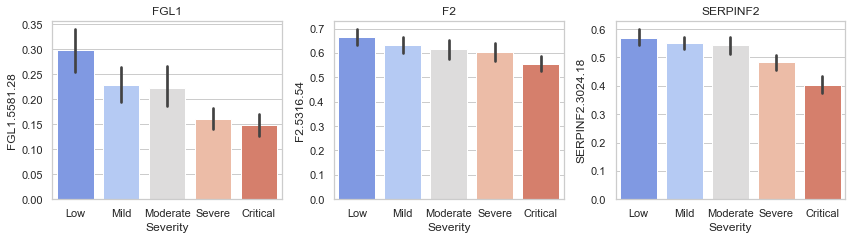

In [14]:
subset_dec = X.filter(items = ['FGL1.5581.28','F2.5316.54','SERPINF2.3024.18'])
plot_figure(1, 3, subset_dec)
#plt.savefig("/Users/smasarone/Documents/decr.pdf")     


In [128]:
### Proteins at least twice as expressedin critical compared to severe and moderate

# check for trends
index_twice= []
for r in means_df.index:
    if means_df.loc[r,"critical"] > means_df.loc[r,"severe"]*2 and means_df.loc[r,"critical"]> means_df.loc[r,"moderate"]*2:
        index_twice.append(r)


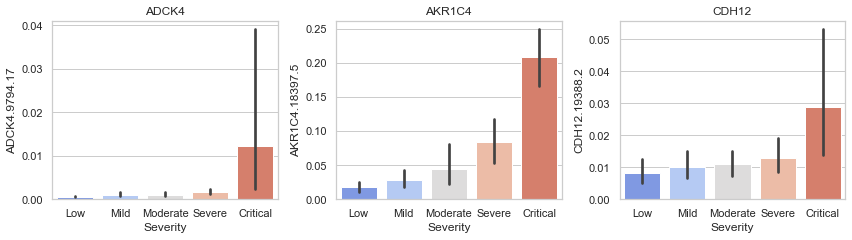

In [129]:
index_twice

subset_dec = X.filter(items = ['ADCK4.9794.17','AKR1C4.18397.5','CDH12.19388.2'])
plot_figure(1, 3, subset_dec)

In [15]:
df_to_use.shape

(414, 47)

No handles with labels found to put in legend.


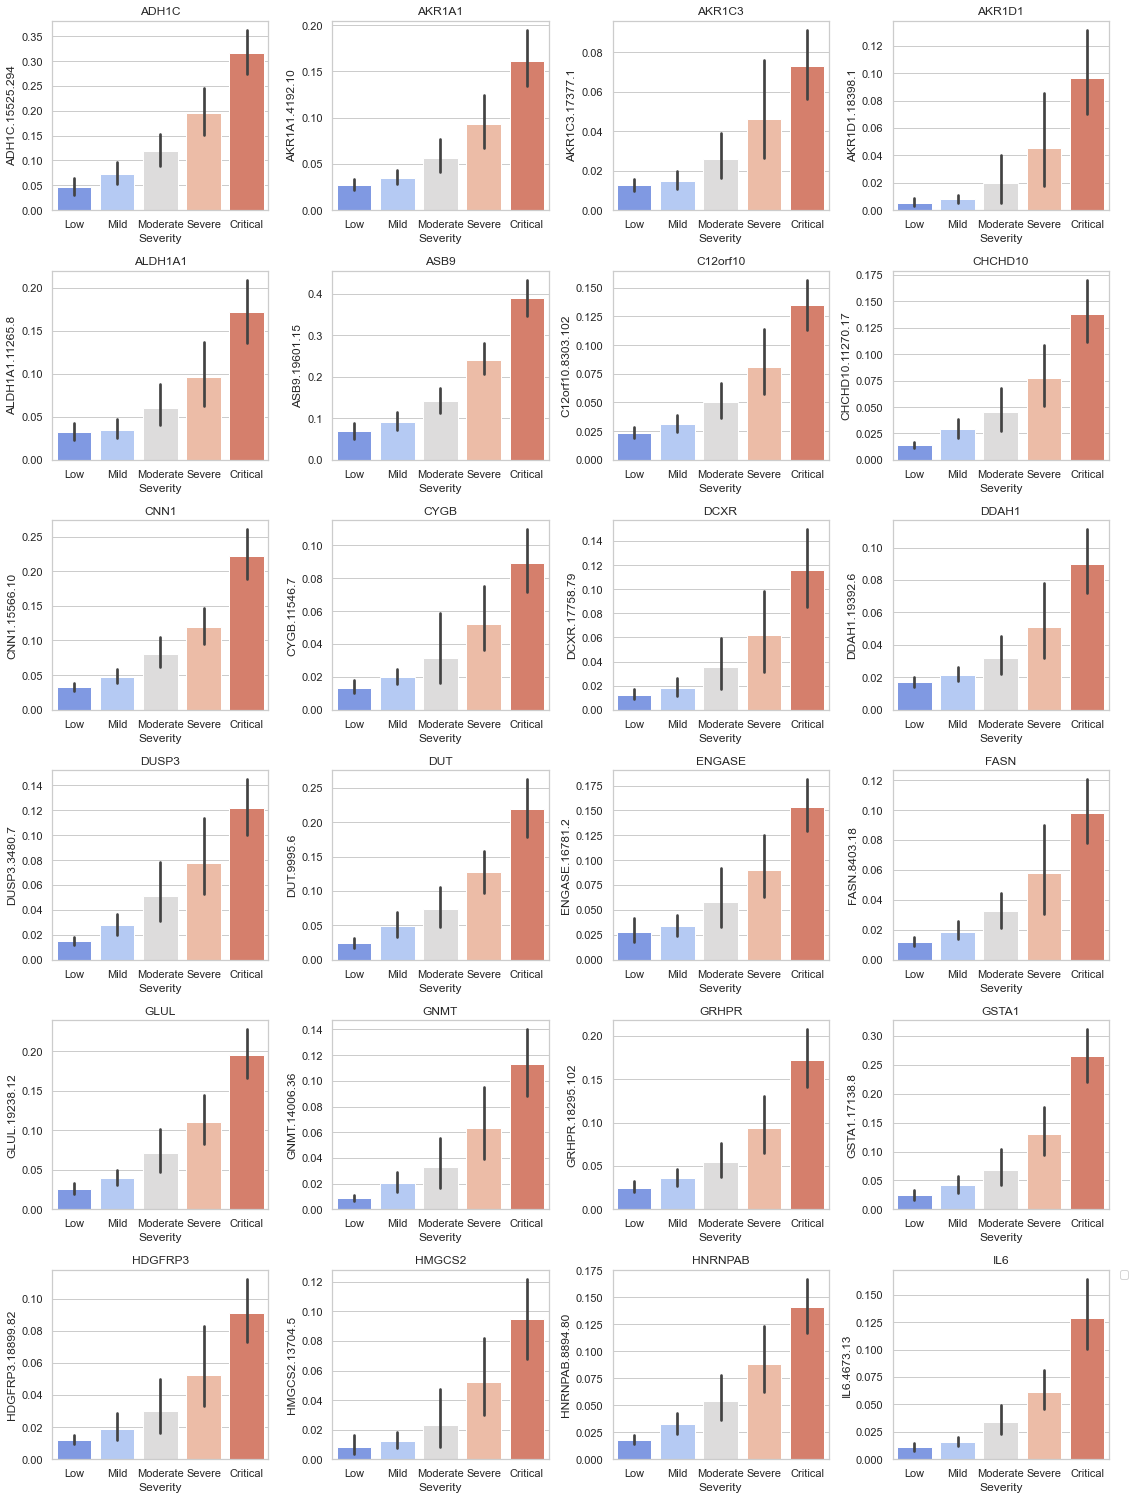

In [20]:
## plot all the exponential proteins
## let's do 24 on each page
# first batch of exponential prot

fig, axs = plt.subplots(6, 4, figsize=(4*4,6*3.5), squeeze=False)
counter=0
for r in range(6):
    for c in range(4):
        if counter>=24:
            break  
        i = df_to_use.columns[0:24][counter]
        sns.barplot(x = clin['Severity'], y = df_to_use.iloc[:,counter], 
            order = ['Low','Mild', 'Moderate','Severe','Critical'], 
            ax = axs[r][c], 
            palette = "coolwarm").set_title(i.split(".")[0])
        #c.title.set_text(i.split(".")[0])
        counter+=1

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout() 


No handles with labels found to put in legend.


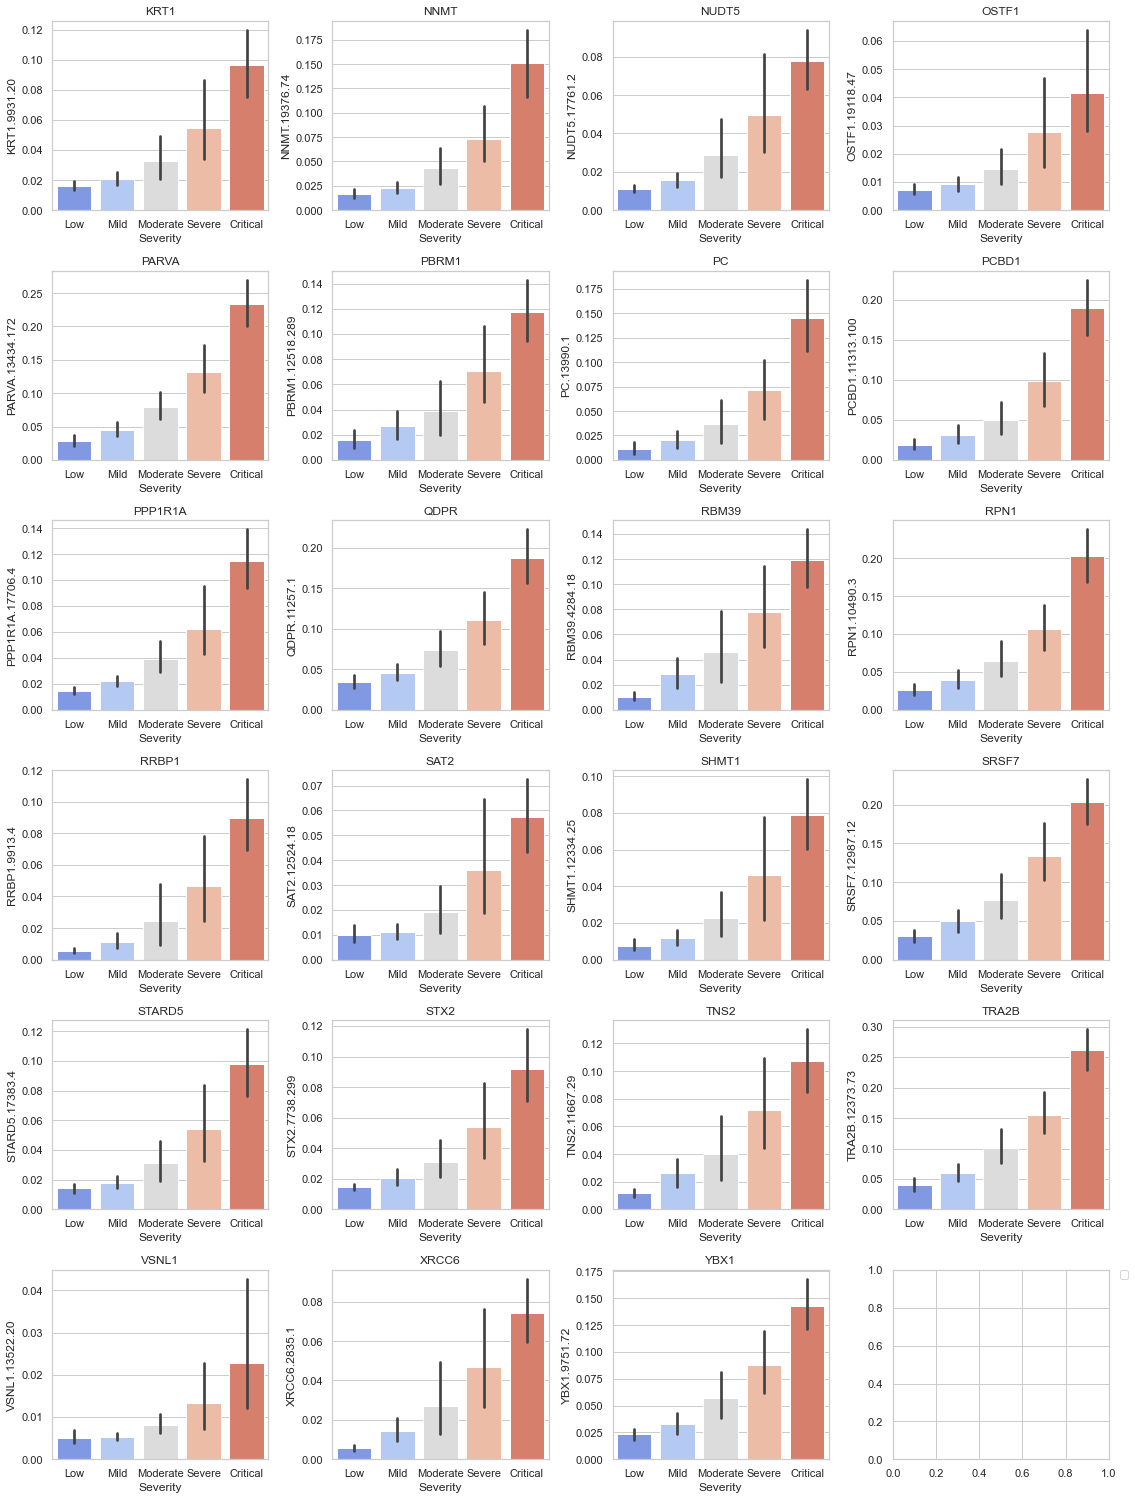

In [25]:
# second batch of exponential prot
fig, axs = plt.subplots(6, 4, figsize=(4*4,6*3.5), squeeze=False)
counter=24
for r in range(6):
    for c in range(4):
        if counter>=47:
            break  
        i = df_to_use.columns[counter]
        sns.barplot(x = clin['Severity'], y = df_to_use.iloc[:,counter], 
            order = ['Low','Mild', 'Moderate','Severe','Critical'], 
            ax = axs[r][c], 
            palette = "coolwarm").set_title(i.split(".")[0])
        #c.title.set_text(i.split(".")[0])
        counter+=1

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout() 
